[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Mayo-Radiology-Informatics-Lab/MIDeL/blob/main/chapters/2-4.ipynb)

*Author: [Author Name]*

## **Image Classification in Medical Imaging**

## Concepts and Definitions

Image classification is one of the fundamental tasks in deep learning and medical imaging.

In classification, we aim to assign a discrete label (or category) to an input image. For example, in medical imaging, we might want to classify:
- Whether a chest X-ray shows pneumonia or is normal
- Wether a histology slide shows benign tissue or malignant
- The severity grade of a disease

In this introductory chapter we'll walk through hands-on code examples training on a medical imaging dataset. Before proceeding to the codes, let's have a brief review of important terminologies in classifcation:

-------
**Binary Classification**: The simplest form where we have only two classes (e.g., disease present vs. absent). The model outputs a single value showing the score (close to but not exactly the probability) of the label being positive.

**Multi-class Classification**: Multiple mutually exclusive classes (e.g., classifying tissue into normal, benign tumor, or malignant tumor). The model output scores for all classes.

**Multi-label Classification**: An image can belong to multiple classes simultaneously (e.g., a chest X-ray showing both pneumonia and pleural effusion).

----------

##### - Neural networks learn this by iterating through these steps:
1. Extracting features from raw image pixels
2. Compute the score for each possible class
3. Selecting the class with the highest score as the final prediction
4. Calculating the loss between predicted versus true (target) class
5. Updating model's weights based on the calculated loss and trainig parameters (learning rate and step size)


##### - A typical classification neural network consists of:
1. **Feature Extraction Layers**: Convolutional layers that learn to extract meaningful features from images
2. **Pooling Layers**: Reduce spatial dimensions while retaining important information
3. **Fully Connected Layers**: Combine features to make final predictions
4. **Output Layer**: Produces class logits which are probabilty estimates for positive classes with a value from -∞ to +∞
5. The **final layer** typically uses:
- **Sigmoid activation** for binary classification (maps logit to a score between 0-1)
- **Softmax activation** for multi-class classification (maps all classes' logits to a score distribution that sums up to 1)

Note: Many people believe teh output value is a probability, but it is not. If it is calibrated (with a separate data set) it does becoem the probabiliyt, but ONLY IF the live data match teh distribution of the calibration set. For that reason, we use the term 'score' rather than 'probability'.

### Setup and Dependencies

First, install the required packages:

In [1]:
# Installing required libraries
!pip install monai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 42.9 MB/s eta 0:00:00


### Importing Libraries

We'll use PyTorch for deep learning, MedMNIST for the dataset, and MONAI for medical imaging-specific models:

In [2]:
# Import the required python types for type hinting
# Turn off the notebook warnings

from typing import List, Tuple, Dict, Union, Callable, Iterable
import warnings
warnings.filterwarnings("ignore")
import torch
import os
import numpy as np
import monai
import random
from functools import wraps
import gdown
import os, numpy as np
from PIL import Image
from collections import Counter
import glob
from tqdm import tqdm

# Set if your google colab run type is set to GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


### Downloading the Dataset

We'll use the Chest X-Ray Pneumonia dataset which contains larger, real-world medical images (normal vs pneumonia classification):


In [3]:
# Download and extract the dataset
if not os.path.isdir('chest_xray'):
    print('Downloading Chest X-Ray dataset...')
    gdown.download(
        "https://drive.google.com/uc?export=download&confirm=pbef&id=1L8ox5fIwb_PijLcPEofQyhe3oGiYESO2",
        "chest_xray.zip",
        quiet=False
    )
    print('Extracting...')
    !unzip -q chest_xray.zip
    os.remove('chest_xray.zip')
    print('Dataset ready!')
else:
    print('Dataset already downloaded.')

# Define dataset configuration
n_channels = 1  # Grayscale
n_classes = 1   # Binary classification: normal vs pneumonia
task = 'binary-class'
batch_size = 32  # Reduced batch size for larger images

!tree -L 2 chest_xray

print(f'\nTask: {task}')
print(f'Number of channels: {n_channels}')
print(f'Number of classes: {n_classes}')

Downloading...
From: https://drive.google.com/uc?export=download&confirm=pbef&id=1L8ox5fIwb_PijLcPEofQyhe3oGiYESO2
To: /content/chest_xray.zip
100%|██████████| 1.24G/1.24G [00:19<00:00, 62.7MB/s]


Extracting...
Dataset ready!
/bin/bash: line 1: tree: command not found

Task: binary-class
Number of channels: 1
Number of classes: 1


You should see the chest_xray dataset in your directory in the left bar:

<br><img src="https://i.ibb.co/N6QYqvg6/photo-5776208569463147497-y.jpg" alt="img1" border="0" height="300"><br><br>

The "sample_data" is uploaded in google colab directories by default. You can remove it.

Now, let's explore the dataset content:

Training set: 5232 images, 2 classes
NORMAL: 1349 | PNEUMONIA: 3883 | ratio=0.35
Number of Gray Scale Images: 954, Number of RGB Images: 46

Test set: 624 images, 2 classes
NORMAL: 234 | PNEUMONIA: 390 | ratio=0.60
Number of Gray Scale Images: 624, Number of RGB Images: 0



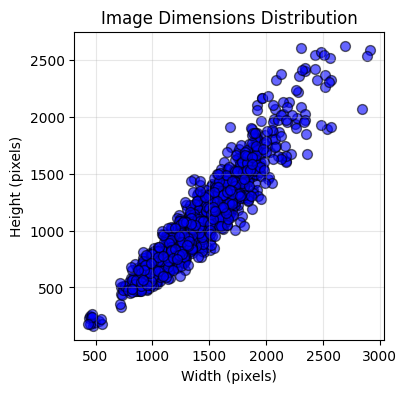

In [4]:
import matplotlib.pyplot as plt

train_dir = 'chest_xray/train'
test_dir = 'chest_xray/test'
class_map = {'NORMAL': 0, 'PNEUMONIA': 1}
num_samples = 1000

# Function to analyze a dataset
def analyze_dataset(data_dir, dataset_name):
    sizes, channels, labels = [], [], []

    for cls, label in class_map.items():
        imgs = glob.glob(f'{data_dir}/{cls}/*.jpeg')
        labels += [label] * len(imgs)
        for f in np.random.choice(imgs, min(num_samples // 2, len(imgs)), replace=False):
            try:
                with Image.open(f) as image:
                    sizes.append(image.size)
                    channels.append(len(image.getbands()))
            except:
                pass

    print(f"{dataset_name} set: {len(labels)} images, {len(class_map)} classes")

    c = Counter(labels)
    r = c[0] / c[1] if len(c) == 2 else 'NA'
    print(f"NORMAL: {c[0]} | PNEUMONIA: {c[1]} | ratio={r:.2f}")

    channel_counts = Counter(channels)
    print(f"Number of Gray Scale Images: {channel_counts[1]}, Number of RGB Images: {channel_counts[3]}\n")

    return sizes, channels

# Analyze both datasets
train_sizes, train_channels = analyze_dataset(train_dir, "Training")
test_sizes, test_channels = analyze_dataset(test_dir, "Test")

w_train, h_train = zip(*train_sizes)

# Plot 1: Image dimensions (width vs height)
plt.figure(figsize=(4, 4))
plt.scatter(w_train, h_train, alpha=0.6, c='blue', edgecolors='black', s=50)
plt.xlabel('Width (pixels)')
plt.ylabel('Height (pixels)')
plt.title('Image Dimensions Distribution')
plt.grid(True, alpha=0.3)
plt.show()


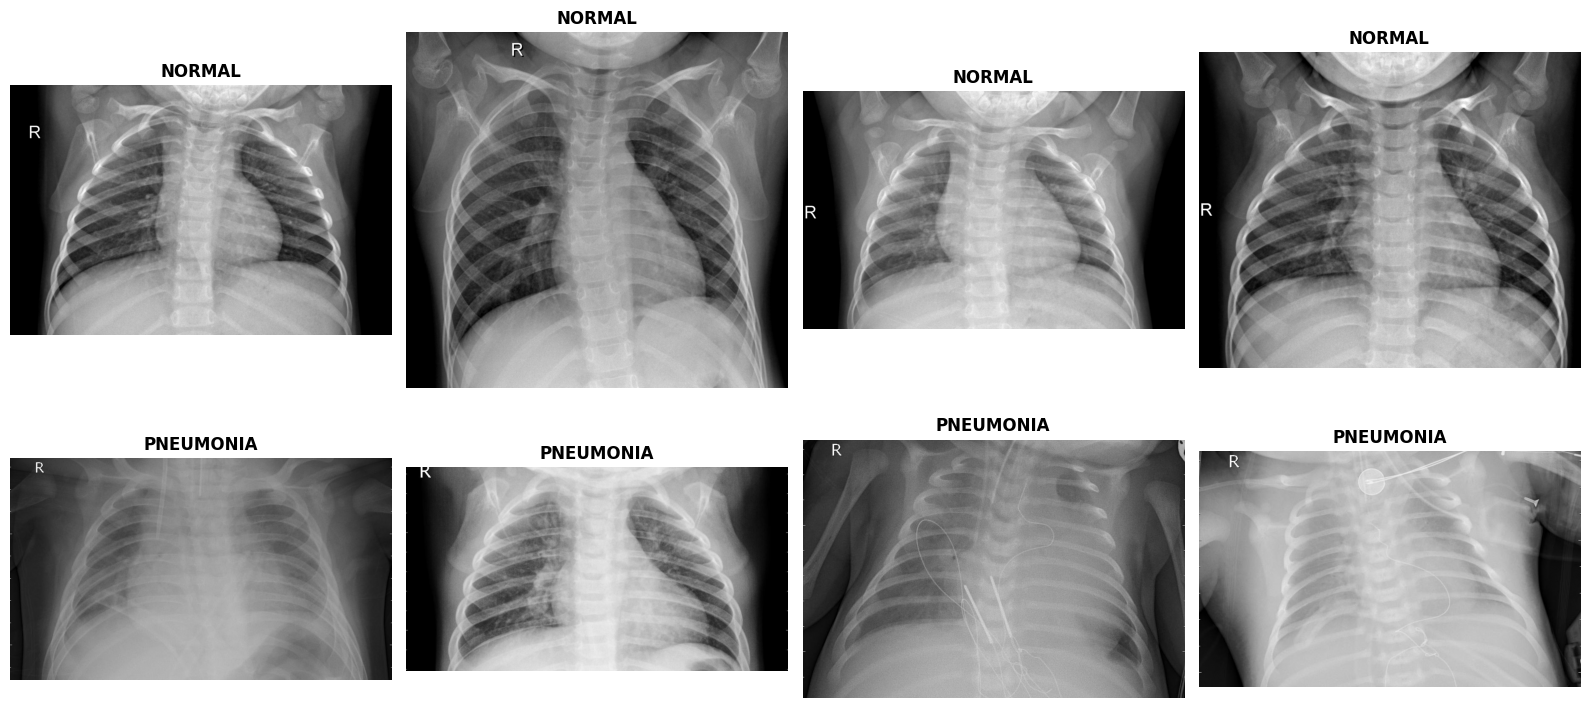

In [5]:
import matplotlib.pyplot as plt
import random

# Get random sample of images
sample_imgs = []
sample_labels = []

for cls, label in class_map.items():
    imgs = glob.glob(f'{train_dir}/{cls}/*.jpeg')
    selected = random.sample(imgs, min(4, len(imgs)))  # 4 images per class
    sample_imgs.extend(selected)
    sample_labels.extend([cls] * len(selected))

# Plot 2x4 grid
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

for idx, (img_path, label) in enumerate(zip(sample_imgs[:8], sample_labels[:8])):
    img = Image.open(img_path)
    axes[idx].imshow(img, cmap='gray')
    axes[idx].set_title(f'{label}', fontsize=12, fontweight='bold')
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

Data investigation shows that the image sizes and the number of channels are not consistent. We need to resize them to a single size and also convert all images to RGB or grayscale, before training.
We first load the images into cutomized datasets for each split (training, validation and test set), then transform them to the desired size and channel.

### Splitting the dataset

The current dataset already has a train and a test split, so we can split the train set to train and validation by 9:1 ratio. This will give us around 500 images which is reasonably representative. Just we should make sure that the proportion of Pneumonia cases remain the same in the training and validation set and a single patient should not be repeated in two differnet sets. In the current dataset, all patients are unique and the directories are already categorized based on Pneumonia classes, so we just splitted each subdirectory of training set and move 0.1 to the validation directory:

In [6]:
import os
import shutil
import random
from pathlib import Path

# Create validation set by splitting train  ing set
val_dir = 'chest_xray/val'
val_ratio= 0.1

# Create val directory structure
for class_name in ['NORMAL', 'PNEUMONIA']:
    os.makedirs(os.path.join(val_dir, class_name), exist_ok=True)

# Move a random 10% of training images to validation
for class_name in ['NORMAL', 'PNEUMONIA']:
    train_class_dir = os.path.join(train_dir, class_name)
    val_class_dir = os.path.join(val_dir, class_name)

    images = [f for f in os.listdir(train_class_dir)
              if f.lower().endswith(('.jpeg'))]

    num_val = int(len(images) * val_ratio)
    val_images = random.sample(images, num_val)

    for img in val_images:
        src = os.path.join(train_class_dir, img)
        dst = os.path.join(val_class_dir, img)
        shutil.move(src, dst)

    print(f'{class_name}: moved {len(val_images)} images to validation')

NORMAL: moved 134 images to validation
PNEUMONIA: moved 388 images to validation


### Customized dataloader

Now we load the images into a standard dataset, transform the images to the same size and dimension, normalize the pixel values to the range of 0 and 1 and output the images and labels in tensor format to be compatible with PyTorch-based frameworks and models.

We will thoroughly discuss each of these steps in chapters 3 and 4.

Just before loading the images to tensors, let's convert them to Gray Scale, then proceed:

In [7]:
# Convert RGB images to grayscale
i=0
j=0
for split in ['train', 'val', 'test']:
    for class_name in ['NORMAL', 'PNEUMONIA']:
        img_paths = glob.glob(f'chest_xray/{split}/{class_name}/*.jpeg')
        i+=len(img_paths)
        for img_path in img_paths:
            img = Image.open(img_path)
            if img.mode != 'L':
                j+=1
                img.convert('L').save(img_path)
print(f'{j} RGB images were converted to Gray Scale (total data size : {i})')

283 RGB images were converted to Gray Scale (total data size : 5856)


In [8]:
from monai.data import Dataset, DataLoader
from monai.transforms import Compose, LoadImaged, EnsureChannelFirstd, Resized, ScaleIntensityd, ToTensord, Lambdad
import glob

# Transform with grayscale conversion
transform = Compose([
    LoadImaged(keys=['image'], image_only=True),  # Load image from path
    EnsureChannelFirstd(keys=['image']),  # Ensure channel first format
    Resized(keys=['image'], spatial_size=(224, 224)),  # Resize
    ScaleIntensityd(keys=['image'], minv=0.0, maxv=1.0),  # Normalize to [0, 1]
    ToTensord(keys=['image'])  # Convert to tensor
])

def create_data_dict(split):
    data_list = []
    for class_name, label in [('NORMAL', 0), ('PNEUMONIA', 1)]:
        img_paths = glob.glob(f'chest_xray/{split}/{class_name}/*.jpeg')
        for img_path in img_paths:
            data_list.append({'image': img_path, 'label': label})
    return data_list

# Create dictionaries for each split
train_data = create_data_dict('train')
val_data = create_data_dict('val')
test_data = create_data_dict('test')

print(f"Train: {len(train_data)} images")
print(f"Val: {len(val_data)} images")
print(f"Test: {len(test_data)} images")

# Create datasets
train_dataset = Dataset(data=train_data, transform=transform)
val_dataset = Dataset(data=val_data, transform=transform)
test_dataset = Dataset(data=test_data, transform=transform)

batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"\nDataLoaders created:")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Train: 4710 images
Val: 522 images
Test: 624 images

DataLoaders created:
Train batches: 148
Val batches: 17
Test batches: 20


Inspect transformed images and labels:

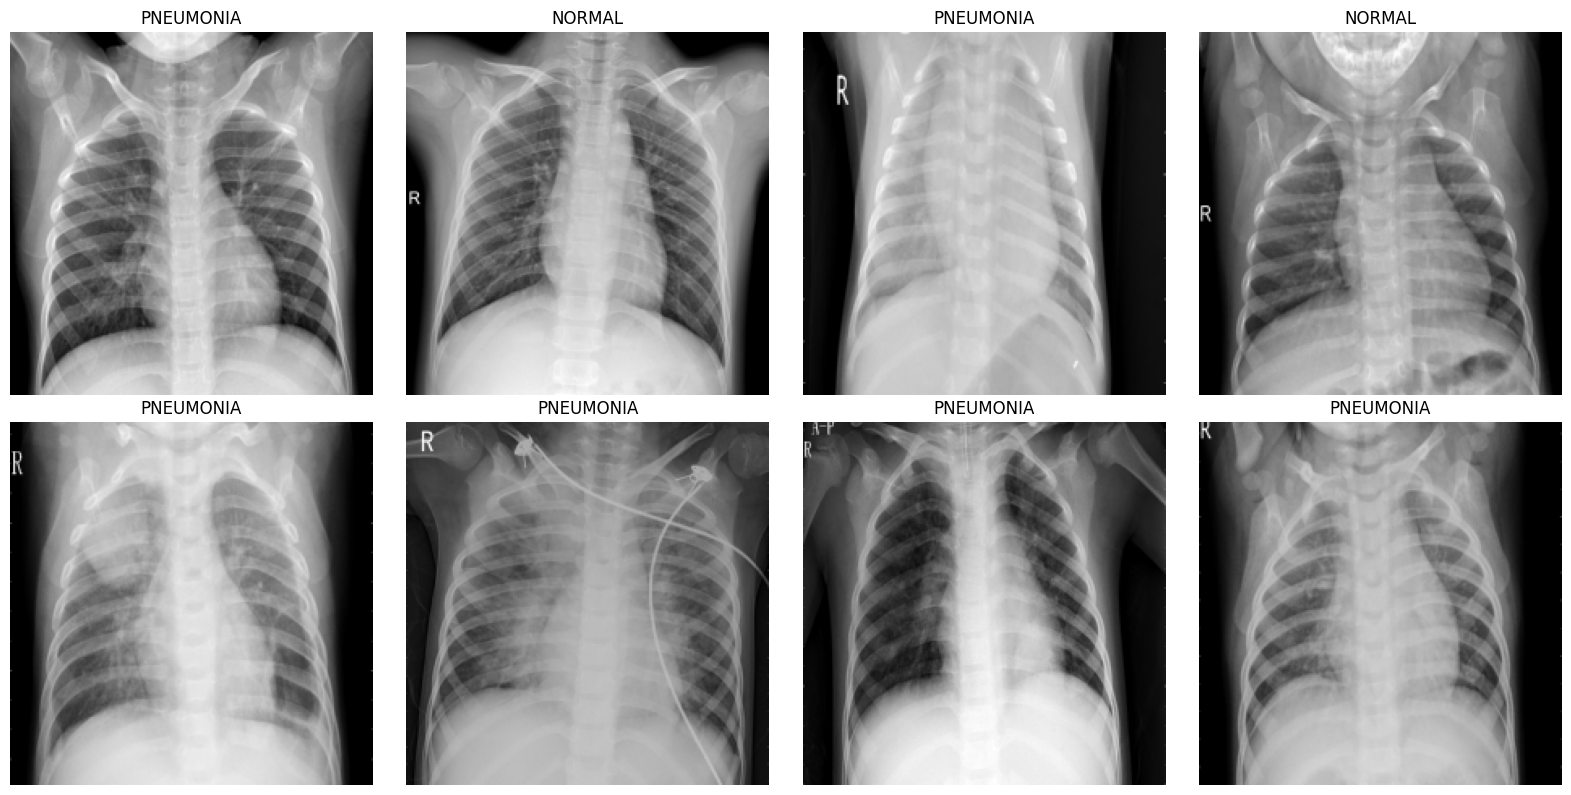

In [18]:
import matplotlib.pyplot as plt

# Get a batch and plot
batch = next(iter(train_loader))
images, labels = batch['image'], batch['label']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for idx, ax in enumerate(axes.ravel()):
    ax.imshow(np.fliplr(np.rot90(images[idx].squeeze().cpu(),k=3)), cmap='gray')
    ax.set_title(['NORMAL', 'PNEUMONIA'][labels[idx]])
    ax.axis('off')
plt.tight_layout()
plt.show()

### Defining the Classification Model Architecture

As we learned in previous chapter, we can create a simple Convolutional Neural Network (CNN), use architecures optimized for processing images, or use pretrained models that are already trained on non-medical or medical images. For this introductory chapter, we use MONAI's DenseNet121, which is specifically designed for medical imaging:


In [10]:
from monai.networks.nets import DenseNet121
from torchsummary import summary
from monai.networks.nets import EfficientNetBN

# EfficientNet-B0 (smallest, ~5M parameters)
model = EfficientNetBN(
    model_name='efficientnet-b0',
    spatial_dims=2,
    in_channels=1,
    num_classes=1
).to(device)

print(f'Model Architecture\n',summary(model, input_size=( 1, 224, 224)))

Downloading: "https://github.com/lukemelas/EfficientNet-PyTorch/releases/download/1.0/efficientnet-b0-355c32eb.pth" to /root/.cache/torch/hub/checkpoints/efficientnet-b0-355c32eb.pth


100%|██████████| 20.4M/20.4M [00:00<00:00, 223MB/s]


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
     ConstantPad2d-1          [-1, 1, 225, 225]               0
            Conv2d-2         [-1, 32, 112, 112]             288
       BatchNorm2d-3         [-1, 32, 112, 112]              64
MemoryEfficientSwish-4         [-1, 32, 112, 112]               0
     ConstantPad2d-5         [-1, 32, 114, 114]               0
            Conv2d-6         [-1, 32, 112, 112]             288
       BatchNorm2d-7         [-1, 32, 112, 112]              64
MemoryEfficientSwish-8         [-1, 32, 112, 112]               0
 AdaptiveAvgPool2d-9             [-1, 32, 1, 1]               0
         Identity-10             [-1, 32, 1, 1]               0
           Conv2d-11              [-1, 8, 1, 1]             264
MemoryEfficientSwish-12              [-1, 8, 1, 1]               0
         Identity-13              [-1, 8, 1, 1]               0
           Conv2d-14            

### Defining Loss Function and Optimizer

Now we need to define the loss function and optimizer for training. Since the dataset is imballanced, we should use weighted loss to prevent the model learn the more prevalent class.

In [11]:
from collections import Counter

# Calculate class weights
train_labels = [sample['label'] for sample in train_data]
class_counts = Counter(train_labels)
pos_weight = torch.tensor([class_counts[0] / class_counts[1]]).to(device)

print(f'Class distribution: NORMAL={class_counts[0]}, PNEUMONIA={class_counts[1]}')
print(f'Positive weight: {pos_weight.item():.3f}')

criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-5)

print(f'Task type: {task}')
print(f'Loss function: {criterion}')
print(f'Optimizer: {optimizer.__class__.__name__}')
print(f'Learning rate: {optimizer.param_groups[0]["lr"]}')

Class distribution: NORMAL=1215, PNEUMONIA=3495
Positive weight: 0.348
Task type: binary-class
Loss function: BCEWithLogitsLoss()
Optimizer: Adam
Learning rate: 0.0001


### Designing the training and validation loop

In [12]:
def train_one_epoch(model, train_loader, criterion, optimizer, device, task='multi-class'):
    """Train for one epoch"""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch in tqdm(train_loader, desc='Training', leave=False):
        images = batch['image'].to(device)
        labels = batch['label'].to(device)
        labels = labels.float()

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)
        outputs= outputs.squeeze()

        # Calculate loss and predictions based on task
        loss = criterion(outputs, labels)
        predicted = (torch.sigmoid(outputs) > 0.5).float()


        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        # Store the metrics for evaluation
        running_loss += loss.item() * images.size(0)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = 100 * correct / total

    return epoch_loss, epoch_acc


def validate(model, val_loader, criterion, device, task='multi-class'):
    """Validate the model"""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for batch in tqdm(val_loader, desc='Validation', leave=False):
            images = batch['image'].to(device)
            labels = batch['label'].to(device)

            # Prepare labels based on task type
            labels = labels.float()

            # Forward pass
            outputs = model(images)
            outputs=outputs.squeeze()

            # Calculate loss and predictions based on task
            loss = criterion(outputs, labels)
            predicted = (torch.sigmoid(outputs) > 0.5).float()

            # Store the metrics for evaluation
            running_loss += loss.item() * images.size(0)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = 100 * correct / total

    return epoch_loss, epoch_acc

### Run the training

In [13]:
# Training configuration
num_epochs = 20
best_val_loss = float('inf')
train_losses, val_losses = [], []
train_accs, val_accs = [], []

print('Starting training...\n')

for epoch in range(num_epochs):
    print(f'Epoch {epoch+1}/{num_epochs}')
    print('-' * 40)

    # Train
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    # Validate
    val_loss, val_acc = validate(model, val_loader, criterion, device)

    # Store metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%')
    print(f'Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%')

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_model.pth')
        print('Saved best model!')

    print()

print('Training complete!')

Starting training...

Epoch 1/20
----------------------------------------


Train Loss: 0.1933 | Train Acc: 89.04%
Val Loss: 45.0119 | Val Acc: 34.29%
Saved best model!

Epoch 2/20
----------------------------------------


Train Loss: 0.0568 | Train Acc: 96.01%
Val Loss: 252.5818 | Val Acc: 42.91%

Epoch 3/20
----------------------------------------


Train Loss: 0.0380 | Train Acc: 97.41%
Val Loss: 206.1219 | Val Acc: 43.30%

Epoch 4/20
----------------------------------------


Train Loss: 0.0204 | Train Acc: 98.54%
Val Loss: 14.7924 | Val Acc: 55.75%
Saved best model!

Epoch 5/20
----------------------------------------


...

Train Loss: 0.0043 | Train Acc: 99.70%
Val Loss: 0.0454 | Val Acc: 97.51%

Epoch 17/20
----------------------------------------


Train Loss: 0.0064 | Train Acc: 99.53%
Val Loss: 0.0436 | Val Acc: 98.47%

Epoch 18/20
----------------------------------------


Train Loss: 0.0034 | Train Acc: 99.64%
Val Loss: 0.0276 | Val Acc: 99.23%

Epoch 19/20
----------------------------------------


Train Loss: 0.0021 | Train Acc: 99.81%
Val Loss: 0.0563 | Val Acc: 98.47%

Epoch 20/20
----------------------------------------


Train Loss: 0.0019 | Train Acc: 99.83%
Val Loss: 0.0845 | Val Acc: 97.70%

Training complete!


Visualize the loss and performance curves during the training and validation

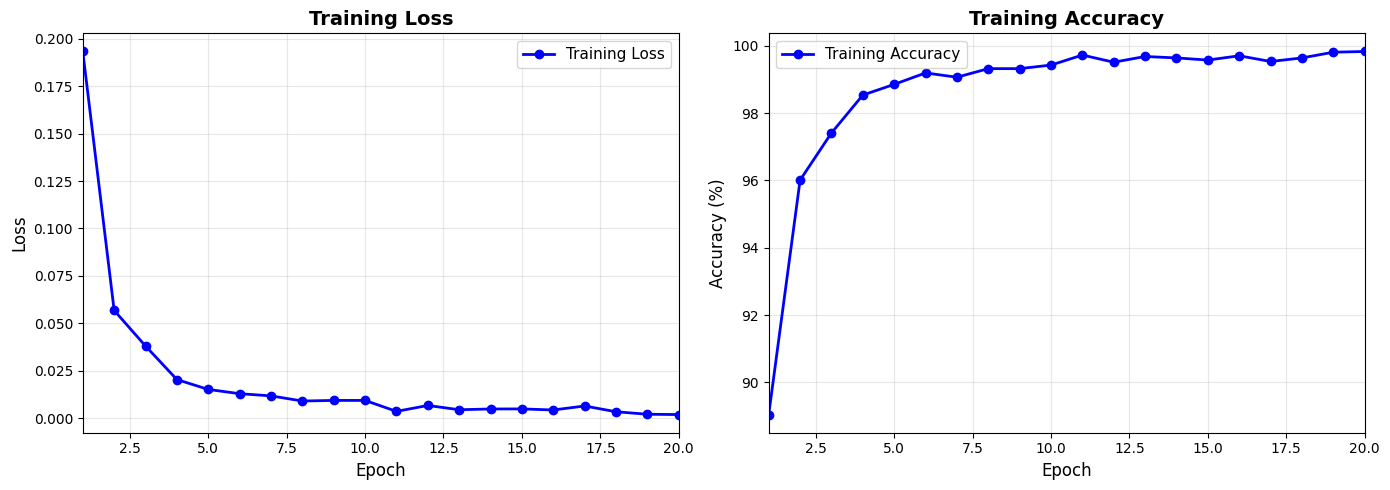

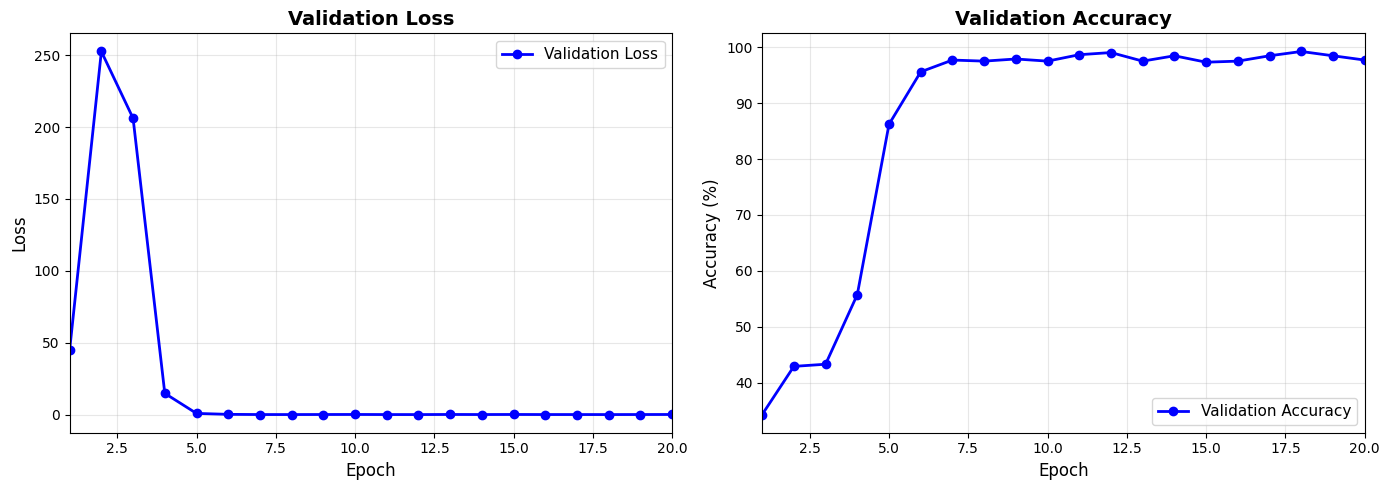


Best Model Performance (Epoch 12):
  Training   - Loss: 0.0067, Acc: 99.51%
  Validation - Loss: 0.0262, Acc: 99.04%


In [14]:
# Plot training and validation metrics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(range(1, num_epochs + 1), train_losses, 'b-o', label='Training Loss', linewidth=2, markersize=6)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training Loss', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(1, num_epochs)
axes[1].plot(range(1, num_epochs + 1), train_accs, 'b-o', label='Training Accuracy', linewidth=2, markersize=6)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1].set_title('Training Accuracy', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(1, num_epochs)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(range(1, num_epochs + 1), val_losses, 'b-o', label='Validation Loss', linewidth=2, markersize=6)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Validation Loss', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(1, num_epochs)
axes[1].plot(range(1, num_epochs + 1), val_accs, 'b-o', label='Validation Accuracy', linewidth=2, markersize=6)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1].set_title('Validation Accuracy', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(1, num_epochs)

plt.tight_layout()
plt.show()

# Print best metrics
best_epoch = val_losses.index(min(val_losses)) + 1
print(f'\n{"="*50}')
print(f'Best Model Performance (Epoch {best_epoch}):')
print(f'{"="*50}')
print(f'  Training   - Loss: {train_losses[best_epoch-1]:.4f}, Acc: {train_accs[best_epoch-1]:.2f}%')
print(f'  Validation - Loss: {val_losses[best_epoch-1]:.4f}, Acc: {val_accs[best_epoch-1]:.2f}%')
print(f'{"="*50}')

Visualize the predictions:

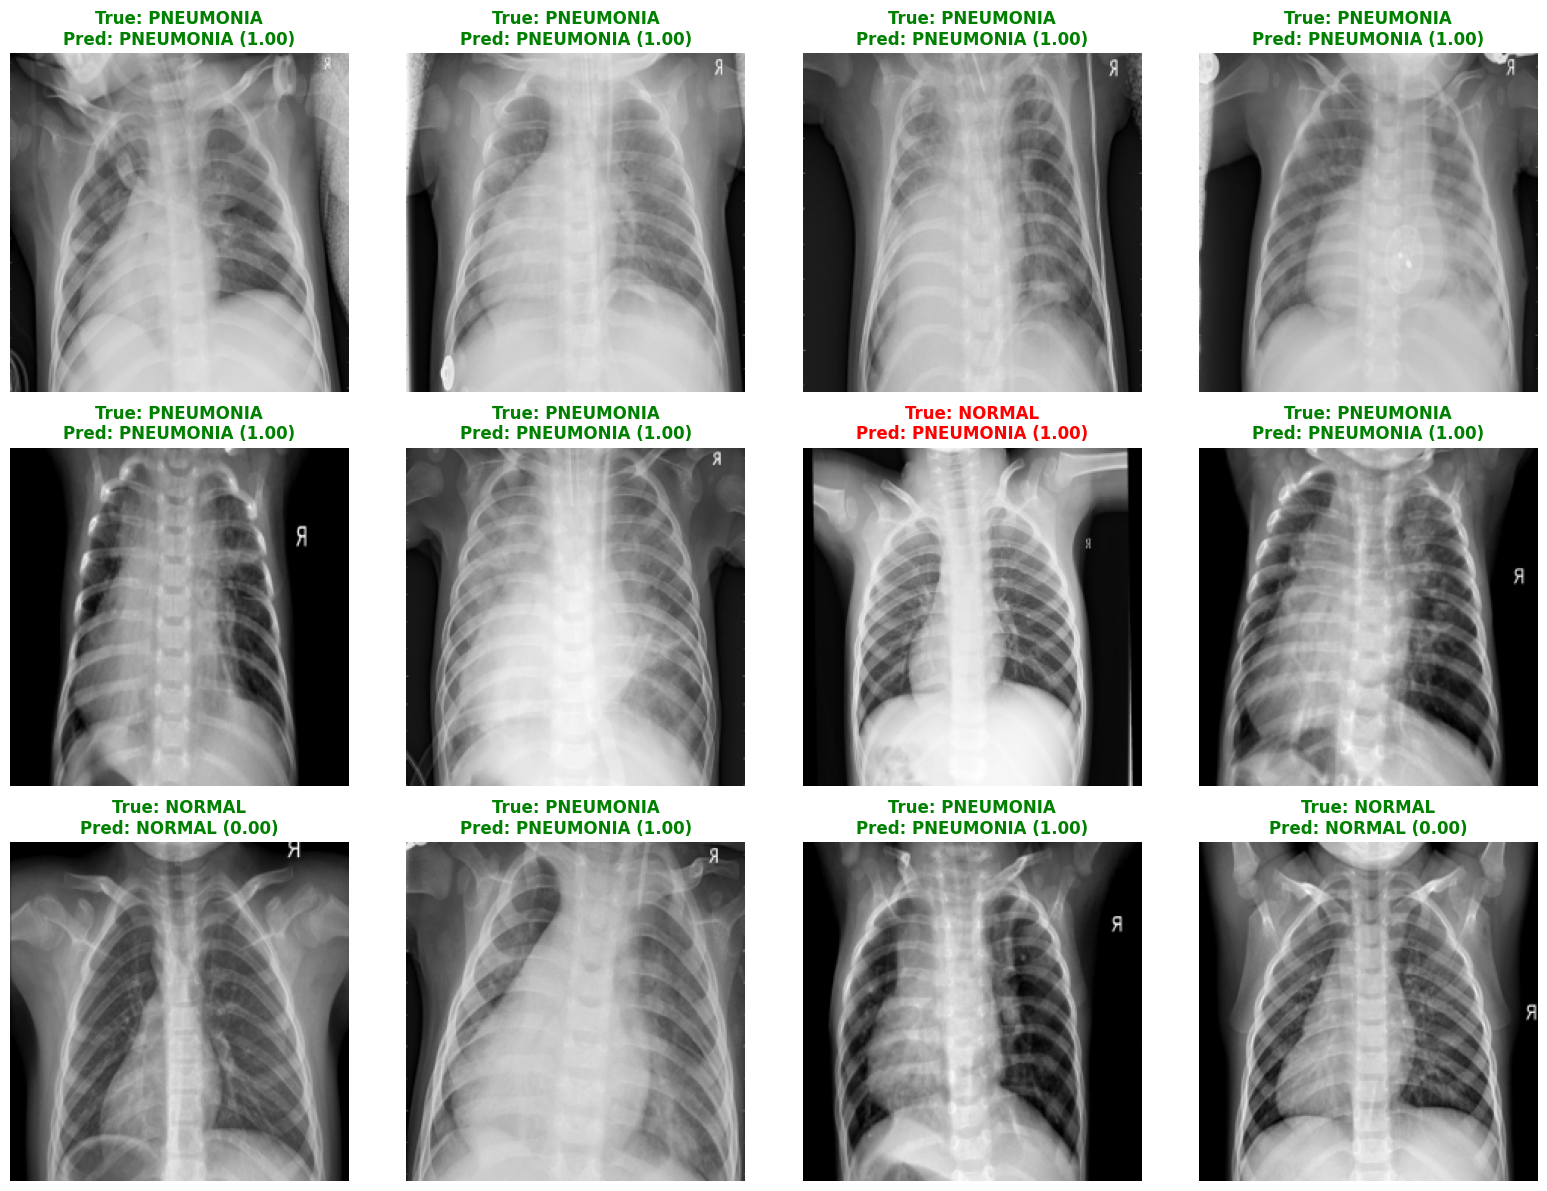

In [17]:
def visualize_predictions(model, dataset, device, num_samples=12):
    """Visualize model predictions on sample images"""
    model.eval()

    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    axes = axes.ravel()

    # Get random samples
    indices = np.random.choice(len(dataset), min(num_samples, len(dataset)), replace=False)

    class_names = ['NORMAL', 'PNEUMONIA']

    with torch.no_grad():
        for idx, ax in zip(indices, axes):
            # Get sample from dataset
            sample = dataset[idx]
            image = sample['image'].to(device)
            label = sample['label']

            # Get prediction
            image_tensor = image.unsqueeze(0)  # Add batch dimension
            output = model(image_tensor)
            prob = torch.sigmoid(output).item()
            predicted = 1 if prob > 0.5 else 0

            # Display image
            img_display = image.squeeze().cpu().numpy()
            ax.imshow(np.rot90(img_display, k=3), cmap='gray')

            # Set title with prediction
            color = 'green' if predicted == label else 'red'
            ax.set_title(f'True: {class_names[label]}\nPred: {class_names[predicted]} ({prob:.2f})',
                        color=color, fontweight='bold')
            ax.axis('off')

    plt.tight_layout()
    plt.show()

# Call the function
visualize_predictions(model, test_dataset, device)